# MANTA - Rigid Alignment

This notebook aligns two tissue slices rigidly using MANTA.

In [1]:
import anndata as ad
import manta

# I/O
from pathlib import Path

In [2]:
%load_ext autoreload
%autoreload 2

## Preprocessing

Before aligning, the slices need to be loaded and preprocessed (see `preprocessing.ipynb` for details).

In [3]:
data_dir = Path("/staging/leuven/stg_00002/lcb/lcb_projects/SPF/mkovacic/data/dataset_MOUSE_BRAIN")

In [4]:
source = ad.read_h5ad(data_dir / "slice_75.h5ad")
target = ad.read_h5ad(data_dir / "slice_76.h5ad")

In [5]:
adatas = manta.preprocessing.preprocess(
    source=source,
    target=target,
    gene_key="gene_name",
    spatial_key="X_spatial_coords"
)

Preprocessing:   0%|          | 0/6 [00:00<?, ?it/s]

In [6]:
manta.sampling.sample(
    adatas=adatas,
    sampler="importance",
    fraction=0.25,
    bin_size=128,
    spatial_key="spatial_manta"
)

In [7]:
source = adatas[0]
target = adatas[1]

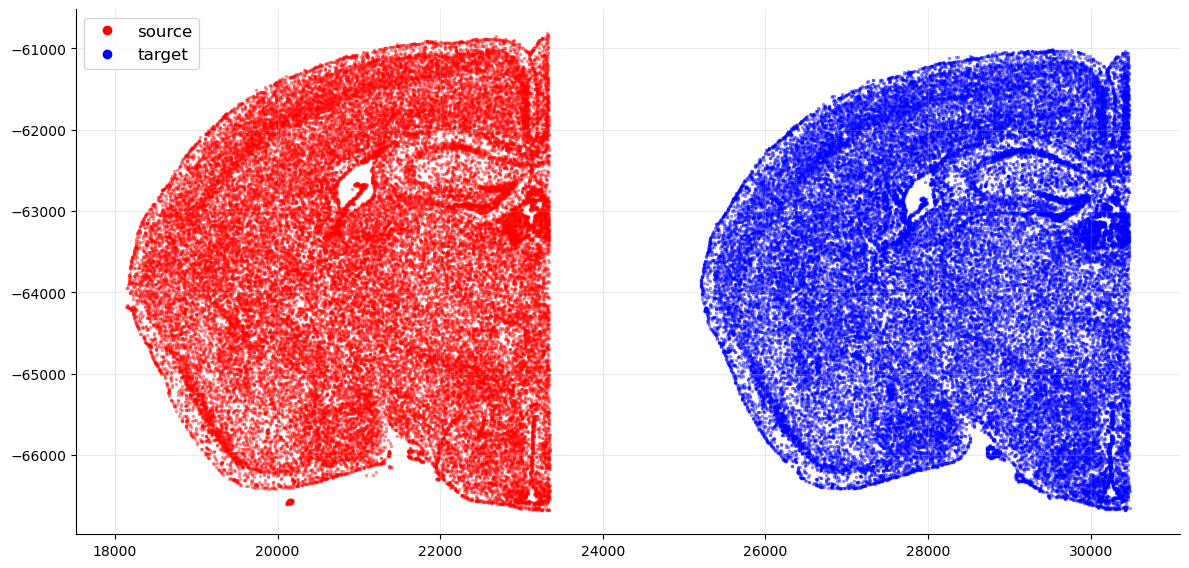

In [8]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],

    figsize=(12,12),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

## Rigid Alignment

After preprocessing, a rigid alignment can be obtained through `manta.alignment.rigid`. Here's a breakdown of all the parameters:

* `source: ad.AnnData`: The source tissue section which will be aligned to the target.
* `target: ad.AnnData`: The target tissue section.
* `voxel_scales: Optional[List[int]] = None`: List of bin sizes to base the rigid alignment on. 
* `min_points_per_voxel: int = 25`: Minimum number of observations for a voxel to be considered valid.
* `min_similarity: float = 0.0`: Minimum similarity for a voxel correspondence to be considered valid.
* `mutual_matching: bool = True`: Requires mutual a correspondence from source to target **and** from target to source to be considered valid.
* `ransac_iters: int = 2000`: Number of RANSAC iterations.
* `ransac_treshold_frac: float = 0.5`: Fraction of the bin size that a correspondence may be "off" in distance to be considered valid.
* `allow_scaling: bool = False`: Allows infering a (isotropic) scaling factor $s$.
* `weight_by_voxel_count: bool = True`: Weight the correspondence strength by the number of observations of a voxel.
* `seed: int = 42`: Seed for reproducability.
* `spatial_key: str = "spatial_manta"`: Key in `source.obsm` and `target.obsm` to retrieve spatial coordinates. 
* `expression_key: str | None = None`: Key in `source.obsm` and `target.obsm` to retrieve expression profiles (e.g. PCA or NMF). By default, the expression matrices `source.X` and `target.X` will be considered if `expression_key is None`.

In [9]:
manta.alignment.rigid(
    source,
    target,
    voxel_scales=[2500, 1000, 500, 250, 125],
    spatial_key="spatial_manta",
    expression_key="X_pca"
)

Rigid Alignment:   0%|          | 0/6 [00:00<?, ?it/s]

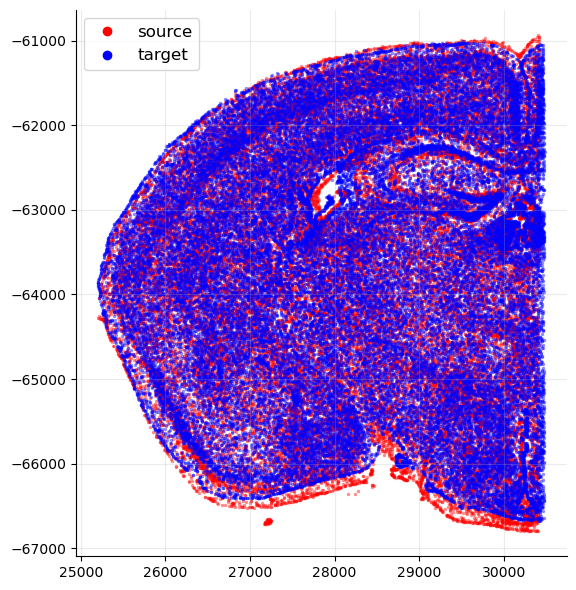

In [10]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    spatial_key="rigid",

    figsize=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

Let's quickly inspect how the rigid registration has evolved over time by inspecting the history. This is particularly helpful **in cases where the rigid registration fails**. 

In [11]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [12]:
history = source.uns["rigid_alignment"]["history"]
voxel_scales = np.array([h["bin_size"] for h in history])

n_matches = np.array([
    h.get("n_matches", np.nan)
    for h in history
], dtype=float)

n_inliers = np.array([
    h.get("n_inliers", np.nan)
    for h in history
], dtype=float)

inlier_ratio = np.array([
    h.get("inlier_ratio", np.nan)
    for h in history
], dtype=float)

mean_cosine_sim = np.array([
    h.get("mean_cosine_sim_inliers", np.nan)
    for h in history
], dtype=float)

metrics = [
    (n_matches, "Number of matches", "Matches"),
    (n_inliers, "Number of inliers", "Inliers"),
    (inlier_ratio, "Inlier ratio", "Inlier ratio"),
    (mean_cosine_sim, "Mean cosine similarity", "Cosine similarity"),
]

In [13]:
def plot_history(metrics):

    fig, axes = plt.subplots(
        1, 4,
        figsize=(18, 6),
        sharey=True,
        constrained_layout=True
    )
    
    for ax, (values, title, xlabel) in zip(axes, metrics):
        ax.plot(values, voxel_scales, marker="o")
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.grid(True, alpha=0.3)
    
    axes[0].set_ylabel("Bin size")
    
    # Metrics with natural [0, 1] range
    axes[2].set_xlim(0, 1)
    axes[3].set_xlim(0, 1)
    
    fig.suptitle("Rigid Alignment Across Voxel Scales", fontsize=14)
    
    plt.show()

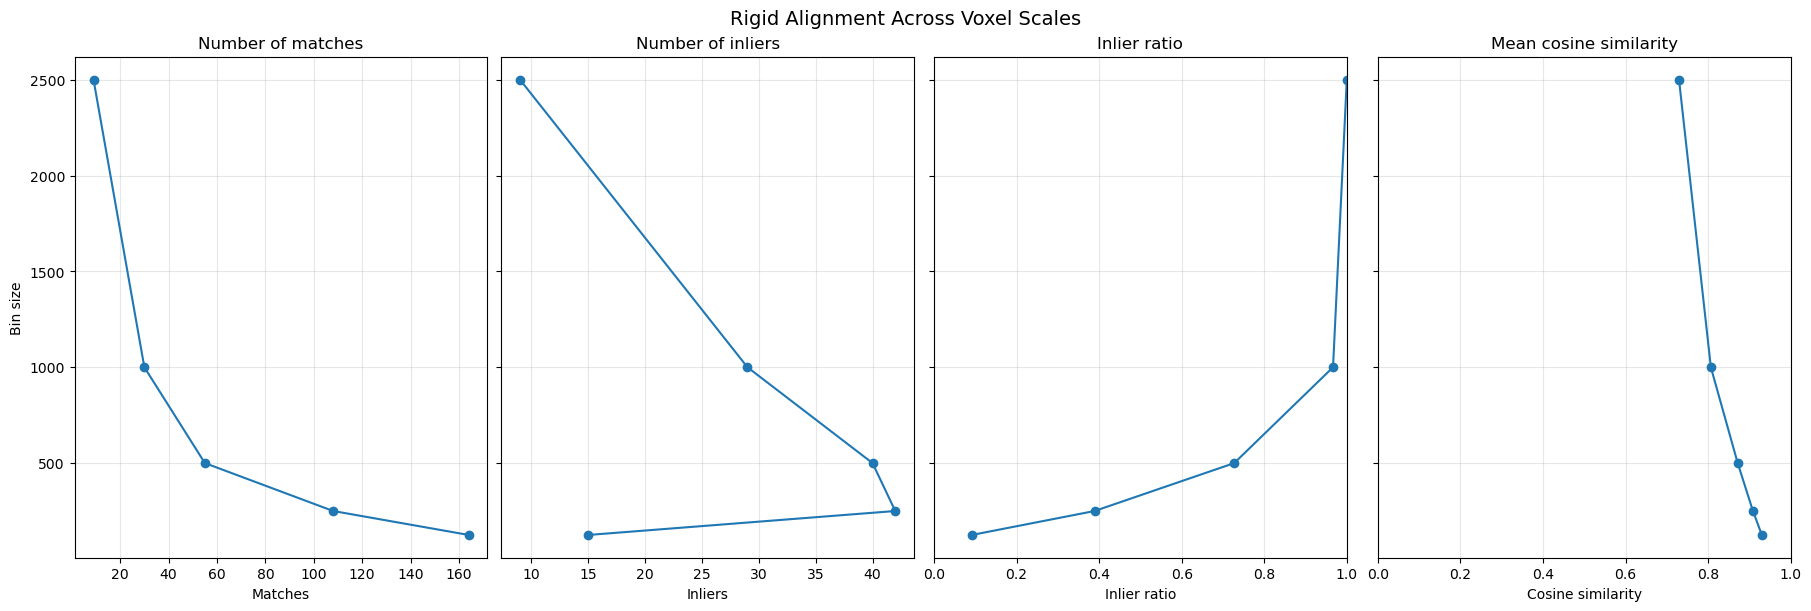

In [14]:
plot_history(metrics)

Let's take the time to interpret these curves. For each bin size, 

* *Number of matches* indicates the number of found matches between bins. As the bin size decreases, the number of matches goes up (as expected). However, simply looking at the number of matches may distort what is actually going on. Instead, we should look at the number of inliers between those matches.
* *Number of inliers* indicates the number of correspondences which explain the optimal transformation. As the bin size decreases, the number of inliers goes up (similar to the number of matches).
* *Inlier ratio* indicates the ratio of inliers vs. the number of total matches. As bin size decreases, the inlier ratio drops. The reason for this will become apparent later.
* *Mean cosine similarity* indicates the average similarity between correspondences that are deemed inliers. As bin size descreases, the similarity ratio goes up.

The conclusion that can be drawn from these curves is that, as bin size decreases, the alignment becomes more robust. Even though a small number of inliers is found at the lowest bin size, the average similarity of inlier voxel pairs is high. Furthermore, the decrease in inliers at the lowest bin size is explained by the fact that the alignment tries to find the most optimal transformation for **all** voxel. Over time, as the bin size decreases, only voxels that are already well aligned will be considered inliers. Other voxels will start exhibiting spatial differences that can not be solved by a rigid transformation only.

## Artificial Displacement

To really see the rigid alignment in action, let's artificially move the observations of the source.

In [15]:
def random_transform(
    points: np.ndarray,
    translation_scale: float = 1.0,
    rotation_scale: float = 1.0,
    scale_range: tuple[float, float] = (0.8, 1.2),
    seed: int | None = None,
):
    points = np.asarray(points, dtype=float)

    if points.ndim != 2:
        raise ValueError("points must have shape (N, D)")

    n, d = points.shape
    rng = np.random.default_rng(seed)

    A = rng.normal(size=(d, d))
    Q, _ = np.linalg.qr(A)

    # Ensure a proper rotation: det(R) = +1
    if np.linalg.det(Q) < 0:
        Q[:, -1] *= -1

    R = Q
    s = rng.uniform(*scale_range)
    t = rng.uniform(
        -translation_scale,
        translation_scale,
        size=d,
    )

    transformed = s * (points @ R.T) + t
    return transformed, R, t, s

In [16]:
source_pts = source.obsm["rigid"]
source_pts_transformed = random_transform(source_pts)[0]

In [17]:
source.obsm["artificial"] = source_pts_transformed
target.obsm["artificial"] = target.obsm["rigid"]

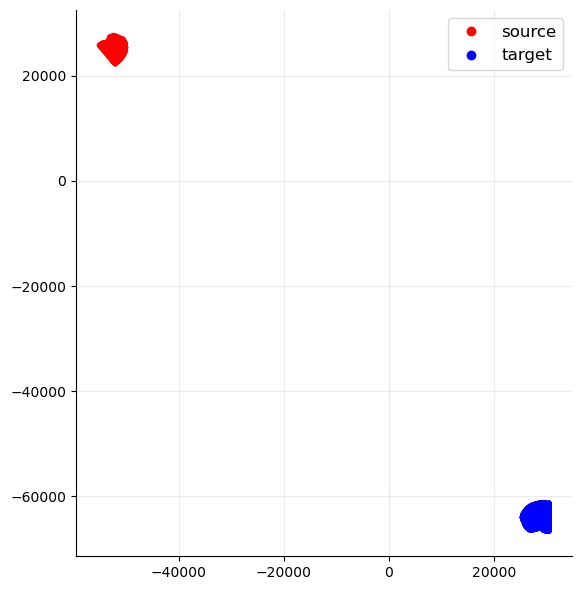

In [18]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    spatial_key="artificial",

    figsize=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

Clearly, these slices are now not aligned anymore! Let's align them using `manta.alignment.rigid`. Since our transform included scaling, let's allow it this time.

In [19]:
manta.alignment.rigid(
    source,
    target,
    voxel_scales=[2500, 1000, 500, 250, 125],
    allow_scaling=True,
    spatial_key="artificial",
    expression_key="X_pca"
)

Rigid Alignment:   0%|          | 0/6 [00:00<?, ?it/s]

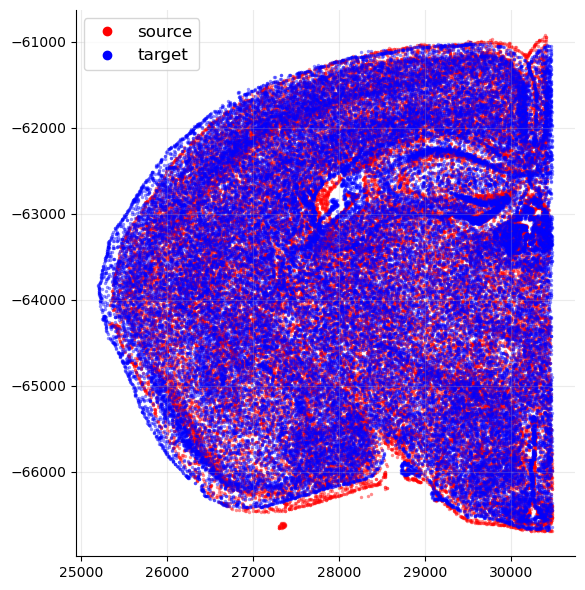

In [20]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    spatial_key="rigid",

    figsize=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

In [21]:
history = source.uns["rigid_alignment"]["history"]
voxel_scales = np.array([h["bin_size"] for h in history])

n_matches = np.array([
    h.get("n_matches", np.nan)
    for h in history
], dtype=float)

n_inliers = np.array([
    h.get("n_inliers", np.nan)
    for h in history
], dtype=float)

inlier_ratio = np.array([
    h.get("inlier_ratio", np.nan)
    for h in history
], dtype=float)

mean_cosine_sim = np.array([
    h.get("mean_cosine_sim_inliers", np.nan)
    for h in history
], dtype=float)

metrics = [
    (n_matches, "Number of matches", "Matches"),
    (n_inliers, "Number of inliers", "Inliers"),
    (inlier_ratio, "Inlier ratio", "Inlier ratio"),
    (mean_cosine_sim, "Mean cosine similarity", "Cosine similarity"),
]

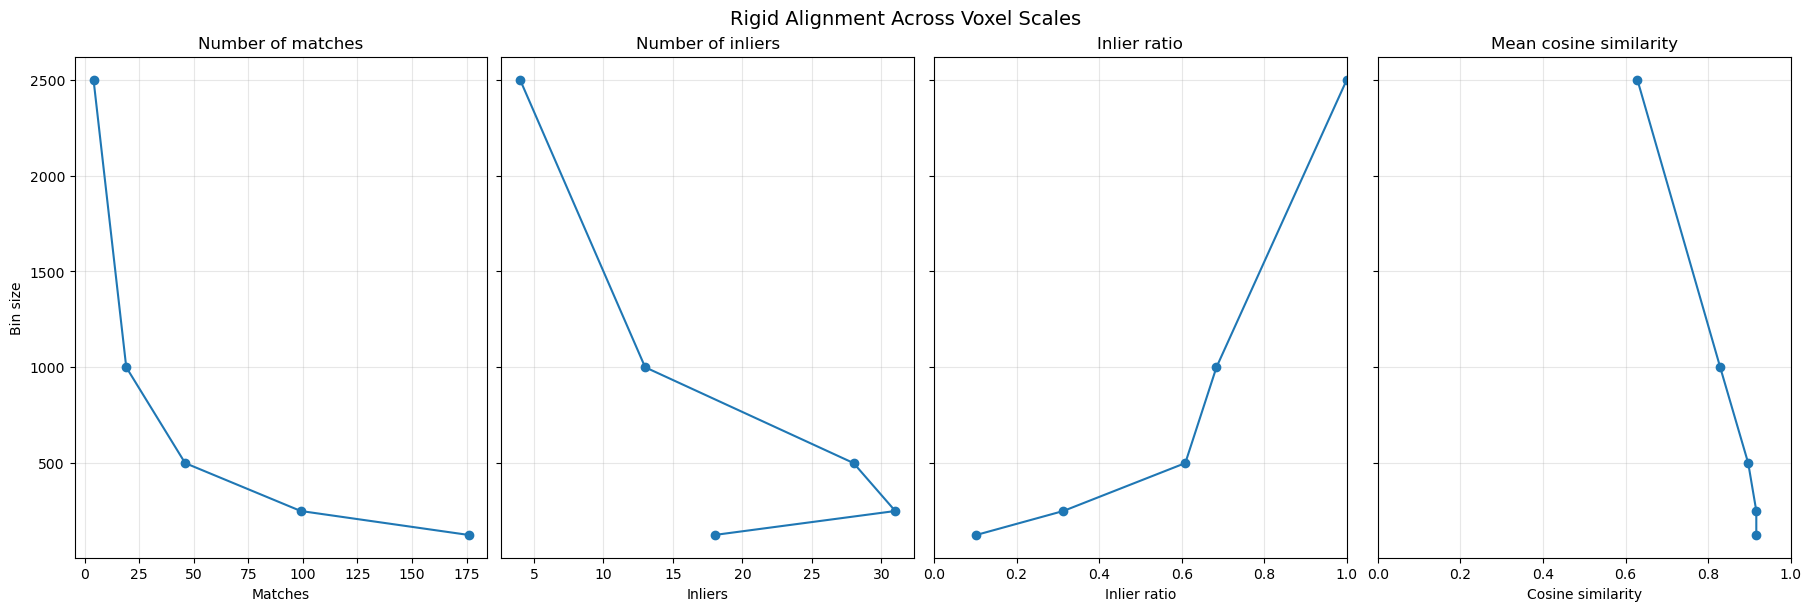

In [22]:
plot_history(metrics)

## GPU-Accelerated Alignment

GPU-accelerated rigid alignment is now also available through `manta.cuda.rigid`. The functionality remains the same, but performance may increase for very large tissue. Note, for smaller tissue sectio

In [23]:
manta.cuda.rigid(
    source,
    target,
    voxel_scales=[2500, 1000, 500, 250, 125],
    spatial_key="spatial_manta",
    expression_key="X_pca"
)

Rigid Alignment:   0%|          | 0/6 [00:00<?, ?it/s]

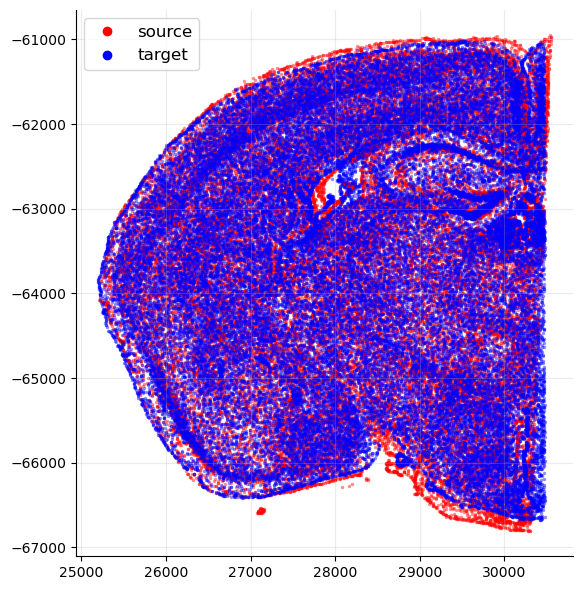

In [24]:
manta.plotting.spatial(
    adatas=adatas,
    labels=["source", "target"],
    colors=["red", "blue"],
    spatial_key="rigid",

    figsize=(6,6),
    alpha=0.45,
    marker_size=6,
    equal_aspect=True
)

## Next Steps

This concludes the rigid alignment step in aligning two tissue slices in MANTA. The next notebook, `encoding.ipynb` will cover the steps required in order to encode a subsampling of the observations in preparation for non-rigid alignment.